In [6]:
import torch
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [5]:
xs = [
    (0, 0),
    (0,	1),
    (1,	0),
    (1,	1),
]
ys = [ 0, 1, 1, 0, ]

In [42]:
from torch import nn

class XorNetwork(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(in_features=2, out_features=8),
            act_fn(),
            nn.Linear(in_features=8, out_features=1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        return self.stack(x)



In [14]:
loss_fn = torch.nn.MSELoss(reduction='sum')

In [20]:
def train(net, xs, ygt, loss_fn, epoch = 20, lr = .1):
    losses = []
    for e in range(epoch):
        # fwd
        y_pred = net(xs)
        # loss
        loss = loss_fn(y_pred, ygt)
        losses.append(loss.item())
        # zero grad
        net.zero_grad()
        # bwd -> recalc gradients
        loss.backward()
        # update ws
        with torch.no_grad():
            for param in net.parameters():
                param -= lr * param.grad
    return losses

In [21]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 

In [35]:
EPOCH = 4000
LEARNING_RATE = .1

In [43]:
model_sigmoid = XorNetwork(nn.Sigmoid).to(device)
model_tanh = XorNetwork(nn.Tanh).to(device)
model_relu = XorNetwork(nn.ReLU).to(device)
model_lrelu = XorNetwork(nn.LeakyReLU).to(device)

xs_ds = torch.tensor(xs, dtype=torch.float32)
ys_ds = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

xs_ds = xs_ds.to(device)
ys_ds = ys_ds.to(device)

In [32]:
print(next(model_sigmoid.parameters()).device, xs_ds.device, ys_ds.device)

mps:0 mps:0 mps:0


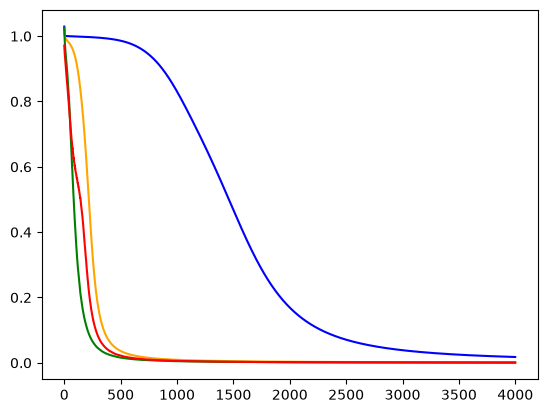

In [44]:
l0 = train(model_sigmoid, xs_ds, ys_ds, loss_fn, EPOCH, LEARNING_RATE)
l1 = train(model_tanh, xs_ds, ys_ds, loss_fn, EPOCH, LEARNING_RATE)
l2 = train(model_relu, xs_ds, ys_ds, loss_fn, EPOCH, LEARNING_RATE)
l3 = train(model_lrelu, xs_ds, ys_ds, loss_fn, EPOCH, LEARNING_RATE)

plt.plot(l0, label="Sigmoid", color="blue")
plt.plot(l1, label="Tanh", color="orange")
plt.plot(l2, label="ReLU", color="green")
plt.plot(l3, label="Leaky ReLU", color="red")
plt.show()

In [45]:
l0[-1], l1[-1], l2[-1], l3[-1]


(0.017796168103814125,
 0.0013447643723338842,
 0.0007036331808194518,
 0.0007391480030491948)

In [ ]:

test_batch = torch.tensor(
    [
        [0.0, 1.0],
        [1.0, 1.0],
        [1.0, 0.0],
        [0.0, 0.0],
    ],
    device=device,
)

models = {
    "Sigmoid": model_sigmoid,
    "Tanh": model_tanh,
    "ReLU": model_relu,
    "LeakyReLU": model_lrelu,
}

print("Inputs order: (0,1), (1,1), (1,0), (0,0)\n" + "-" * 40)

for name, model in models.items():
    # Pass the whole batch through the model at once
    outputs = model(test_batch).squeeze().tolist()
    
    # Format each float neatly
    formatted_outputs = [f"{val:.4f}" for val in outputs]
    print(f"{name:<10}: {formatted_outputs}")

Inputs order: (0,1), (1,1), (1,0), (0,0)
----------------------------------------
Sigmoid   : ['0.9281', '0.0756', '0.9385', '0.0558']
Tanh      : ['0.9808', '0.0203', '0.9810', '0.0143']
ReLU      : ['0.9884', '0.0086', '0.9884', '0.0190']
LeakyReLU : ['0.9855', '0.0110', '0.9887', '0.0168']
